# Pine Biomass Project


In [1]:
import torch
import pandas as pd
from CPRModelFitter import CPRModelFitter

### Function for Creating a Tensor

In [2]:
def create_tensor(df: pd.DataFrame) -> torch.tensor:
    x = df["y"].values 
    x = (x - x.min()) / (x.max() - x.min()) * 31
    tensor_x = torch.tensor(x, dtype=torch.float32)
    tensor_y = torch.tensor(df["sp_binary"].values, dtype=torch.float32)
    return tensor_x, tensor_y

###  Creating the dataframe and finding the species count

In [5]:
sheets = pd.read_excel("CooksBranch.xlsx", sheet_name=None)
df1 = sheets["CooksBranch_trees_2026_0"]
df2 = sheets["CooksBranch_stems_1"] # multi stem datasheet
df2 = df2.merge(df1[['tag', 'x', 'y']], on='tag', how='left') # put the x and y coordinates on the multistems
df1 = df1[['tag', 'StemTag', 'DBH_CURRENT', 'spcode', 'x','y']]
df2 = df2[['tag', 'StemTag', 'DBH_CURRENT', 'spcode', 'x','y']]
df = pd.concat([df1, df2]) # put multistems into the main dataset to treat them as individual trees
#Filter for the columns used in the distribution boundary analysis
df = df[df["tag"] < 38000]
# Filter for Shortleaf and Loblolly pine
pine_df = df[df['spcode'].isin(['PINTAE', 'PINECH'])]
print(pine_df['spcode'].value_counts())

/Users/andrewbuckland/Desktop/Projects/CBCPineBiomass/env/lib/python3.13/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


spcode
PINTAE    2712
PINECH     540
Name: count, dtype: int64


### Modeling the significant change between probability of a loblolly vs shortleaf pine

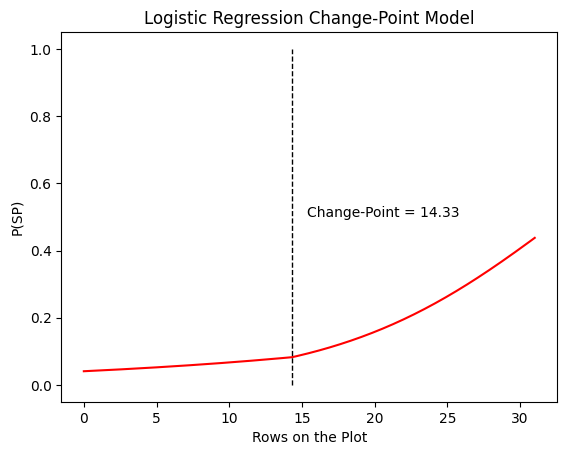

In [4]:
# Mapping PINTAE to 0 and PINECH to 1
pine_df['sp_binary'] = pine_df['spcode'].map({'PINTAE': 0, 'PINECH': 1})
tensor_x, tensor_y = create_tensor(pine_df)
model = CPRModelFitter(tensor_x, tensor_y, 1)
model.fit_change_point_model()
model.plt_model()